### Вы — аналитик данных, и сейчас идёте в стартап, который создает новый маркетплейс. Он недавно появился на рынке и занимается продажей новых товаров из Бразилии, которые только начинают поступать в продажу.

Продакт-менеджер Петя переживает за свой продукт, так как выручка маркетплейса стоит на месте уже несколько месяцев. Он предложил вам полную свободу действий. Главное — чтобы метрики росли, а мы не причиняли неудобства клиентам, ведь Петя заботится об их опыте.

Файлы:

1) olist_customers_dataset.csv — таблица с уникальными идентификаторами пользователей
- customer_id — позаказный идентификатор пользователя

- customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)

- customer_zip_code_prefix — почтовый индекс пользователя

- customer_city — город доставки пользователя

- customer_state — штат доставки пользователя

2) olist_orders_dataset.csv —  таблица заказов
- order_id — уникальный идентификатор заказа (номер чека)

- customer_id — позаказный идентификатор пользователя

- order_status — статус заказа

- order_purchase_timestamp — время создания заказа

- order_approved_at — время подтверждения оплаты заказа

- order_delivered_carrier_date — время передачи заказа в логистическую службу

- order_delivered_customer_date — время доставки заказа

- order_estimated_delivery_date — обещанная дата доставки

3) olist_order_items_dataset.csv — товарные позиции, входящие в заказы
order_id — уникальный идентификатор заказа (номер чека)

- order_item_id — идентификатор товара внутри одного заказа

- product_id — ид товара (аналог штрихкода)

- seller_id — ид производителя товара

- shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике

- price — цена за единицу товара

- freight_value — вес товара 

## Задача 1: Оценить месячный retention в оформление заказа с помощью когортного анализа.

In [1]:
#импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

In [2]:
#загрузка данных
customers = pd.read_csv('olist_customers_dataset.csv', encoding = 'utf-8')
orders = pd.read_csv('olist_orders_dataset.csv', encoding = 'utf-8')
items = pd.read_csv('olist_order_items_dataset.csv', encoding = 'utf-8')

In [3]:
#проверка данных
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.shape

(99441, 5)

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders.shape

(99441, 8)

In [7]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
items.shape

(112650, 7)

In [9]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [10]:
#в orders колонки с датой преобразовываем в datetime

ord_cols_names = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
'order_delivered_customer_date', 'order_estimated_delivery_date']

for d in ord_cols_names:
    orders[d] = pd.to_datetime(orders[d])


In [11]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [12]:
orders.groupby('order_status').order_id.count()

order_status
approved           2
canceled         625
created            5
delivered      96478
invoiced         314
processing       301
shipped         1107
unavailable      609
Name: order_id, dtype: int64

In [13]:
# Для retention учитываем только доставленные заказы
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

In [14]:
orders_with_customers = delivered_orders.merge(
    customers[['customer_id', 'customer_unique_id']], 
    on='customer_id')

In [15]:
orders_with_customers

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6
...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c


In [16]:
#находим дату первого заказа каждого пользователя (order_purchase_timestamp)

first_order = orders_with_customers.groupby('customer_unique_id').order_purchase_timestamp.min().reset_index().rename(columns={'order_purchase_timestamp': 'first_order_date'})

In [17]:
first_order

,customer_unique_id,first_order_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42
...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36
93354,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56
93355,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16
93356,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41


In [18]:
#Создание когорт
cohort_data = orders_with_customers.merge(first_order, on = 'customer_unique_id', how = 'left')

In [19]:
cohort_data

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,first_order_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,2017-09-04 11:26:38
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39
...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09 09:54:05
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,2018-02-06 12:58:58
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,2017-08-27 14:46:43
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,2018-01-08 21:28:27


In [20]:
#Создаем когорту (год-месяц первого заказа)
cohort_data['cohort'] = cohort_data['first_order_date'].dt.to_period('M')
cohort_data['order_month'] = cohort_data['order_purchase_timestamp'].dt.to_period('M')

In [21]:
cohort_data

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,first_order_date,cohort,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,2017-09-04 11:26:38,2017-09,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02,2018-02
...,...,...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09 09:54:05,2017-03,2017-03
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,2018-02-06 12:58:58,2018-02,2018-02
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,2017-08-27 14:46:43,2017-08,2017-08
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,2018-01-08 21:28:27,2018-01,2018-01


In [22]:
#всего когорт:
cohort_data['cohort'].nunique()

23

In [23]:
#группируем по когорте и месяцу заказа
cohort_group = cohort_data.groupby(['cohort', 'order_month']) \
.agg(n_customers=('customer_unique_id', 'nunique')) \
.reset_index()

In [24]:
cohort_group

,cohort,order_month,n_customers
0,2016-09,2016-09,1
1,2016-10,2016-10,262
2,2016-10,2017-04,1
3,2016-10,2017-07,1
4,2016-10,2017-09,1
...,...,...,...
214,2018-06,2018-07,25
215,2018-06,2018-08,16
216,2018-07,2018-07,5949
217,2018-07,2018-08,31


In [25]:
#расчет retention
cohort_group['cohort_period'] = (cohort_group['order_month'] - cohort_group['cohort']).apply(
    lambda x: x.n if pd.notnull(x) else 0
)

In [26]:
cohort_group

,cohort,order_month,n_customers,cohort_period
0,2016-09,2016-09,1,0
1,2016-10,2016-10,262,0
2,2016-10,2017-04,1,6
3,2016-10,2017-07,1,9
4,2016-10,2017-09,1,11
...,...,...,...,...
214,2018-06,2018-07,25,1
215,2018-06,2018-08,16,2
216,2018-07,2018-07,5949,0
217,2018-07,2018-08,31,1


In [27]:
#Создаем сводную таблицу для когортного анализа
retention_matrix = cohort_group.pivot_table(
    index='cohort',
    columns='cohort_period',
    values='n_customers',
    aggfunc='sum',
    fill_value=0
)

In [28]:
retention_matrix

cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2016-10,262,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,1,2,2
2016-12,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2017-01,717,2,2,1,3,1,3,1,1,0,3,1,5,3,1,1,2,3,1,0
2017-02,1628,3,5,2,7,2,4,3,2,3,2,5,2,3,2,1,1,3,0,0
2017-03,2503,11,9,10,9,4,4,8,8,2,9,3,5,3,4,6,2,3,0,0
2017-04,2256,14,5,4,6,6,8,7,7,4,6,2,1,1,2,2,3,0,0,0
2017-05,3451,16,16,10,10,11,14,5,9,9,9,12,8,1,6,7,0,0,0,0
2017-06,3037,15,12,13,9,12,11,7,4,6,9,11,5,5,7,0,0,0,0,0


In [29]:
# размер когорты (месяц 0)
cohort_size = retention_matrix[0]

# расчет retention rate в процентах
retention_rate = retention_matrix.divide(cohort_size, axis=0) * 100

In [30]:
retention_rate.head()

cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,100.0,0.000000,0.000000,0.00000,0.000000,0.00000,0.381679,0.000000,0.00000,0.381679,0.00000,0.381679,0.00000,0.381679,0.00000,0.381679,0.000000,0.381679,0.763359,0.763359
2016-12,100.0,100.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01,100.0,0.278940,0.278940,0.13947,0.418410,0.13947,0.418410,0.139470,0.13947,0.000000,0.41841,0.139470,0.69735,0.418410,0.13947,0.139470,0.278940,0.418410,0.139470,0.000000
2017-02,100.0,0.184275,0.307125,0.12285,0.429975,0.12285,0.245700,0.184275,0.12285,0.184275,0.12285,0.307125,0.12285,0.184275,0.12285,0.061425,0.061425,0.184275,0.000000,0.000000


In [31]:
#анализ результатов
#медианный retention 1-го месяца
median_retention_1m = retention_rate[1].median()

median_retention_1m

0.46363372935381053

In [32]:
# Когорта с самым высоким retention на 3-й месяц
if 3 in retention_rate.columns:
    best_cohort_3m = retention_rate[3].idxmax()
    best_retention_3m = retention_rate[3].max()
    print(f"{best_cohort_3m} - {best_retention_3m:.3f}%")
else:
    print("Данные за 3-й месяц отсутствуют")


2017-06 - 0.428%


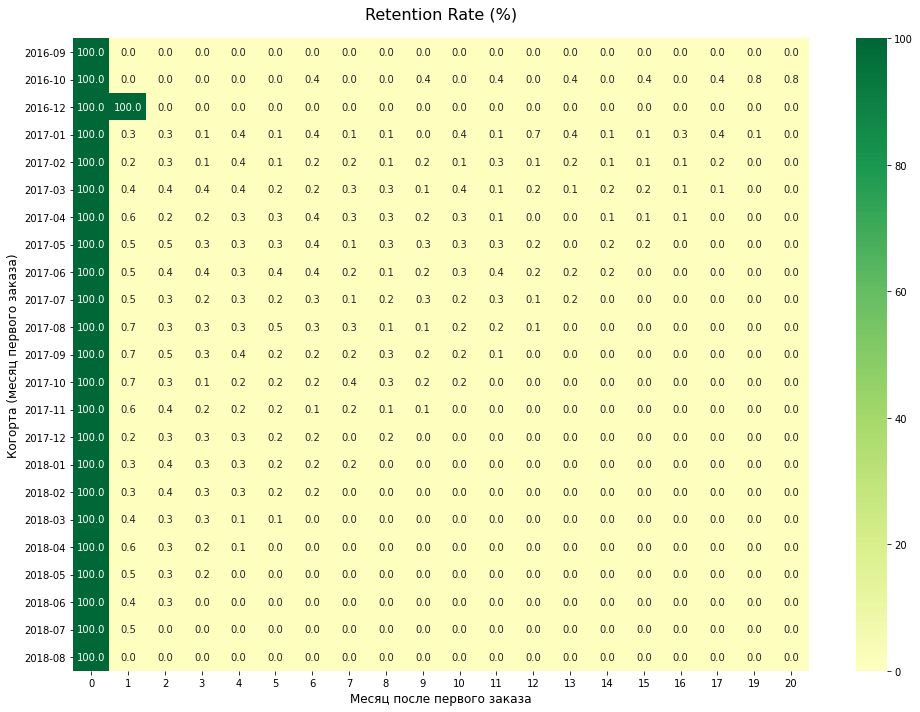

In [33]:
# Строим тепловую карту когортного анализа
plt.figure(figsize=(14, 10))

# Тепловая карта для коэффициентов удержания (в процентах)
sns.heatmap(retention_rate,
            mask=retention_rate.isnull(), #скрывает пустые/NaN ячейки
            annot=True, #включает отображение числовых значений внутри ячеек 
            fmt='.1f',
            cmap='RdYlGn', #цветовая палитра
            center=0 #центрирует цветовую шкалу на нуле
           )

plt.title('Retention Rate (%)', fontsize=16, pad=20)
plt.xlabel('Месяц после первого заказа', fontsize=12)
plt.ylabel('Когорта (месяц первого заказа)', fontsize=12)
plt.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

### Выводы:

- **1. Медианный retention 1-го месяца: 0.46%**

Это крайне низкий показатель. Только 0.46% пользователей возвращаются через месяц после первой покупки.
- **2. Когорта с лучшим retention на 3-й месяц: 2017-06 (0.43%)**

Это означает, что из 1000 пользователей только 4 вернутся через 3 месяца.


## Задача 2. Определить, существует ли product/market fit у маркетплейса.

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

Для этого вам нужно:

Определить, существует ли product/market fit у этого маркетплейса. Ведь до сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

В рамках исследования необходимо:

Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

In [34]:
# Расчет критических метрик
first_month_retention = retention_rate[1].mean()
third_month_retention = retention_rate[3].mean() if 3 in retention_rate.columns else 0
cohorts_with_any_retention = (retention_rate.iloc[:, 1:] > 0).any(axis=1).mean() * 100

print(f"Средний retention 1-го месяца: {first_month_retention:.3f}%")
print(f"Средний retention 3-го месяца: {third_month_retention:.3f}%")
print(f"Когорт с хоть каким-то retention: {cohorts_with_any_retention:.1f}%")
print(f"Медианный размер повторных покупок: {retention_matrix.iloc[:, 1:].median().median()} пользователей")

print("product/market fit у маркетплейса отсутствует")

Средний retention 1-го месяца: 4.741%
Средний retention 3-го месяца: 0.185%
Когорт с хоть каким-то retention: 91.3%
Медианный размер повторных покупок: 0.0 пользователей
product/market fit у маркетплейса отсутствует


### Возможные причины отсутствия PMF
- **1. Качество товара/услуги**

Товары не соответствуют ожиданиям, возможно низкое качество или несоответствие описанию

- **2. Проблемы с доставкой**

Долгие сроки доставки из-за международной логистики, высокая стоимость доставки 

- **3. Ценовая политика**

- **4. Пользовательский опыт**

Сложный процесс заказа, плохая поддержка клиентов, неудобный возврат товаров

#### PRODUCT/MARKET FIT ОТСУТСТВУЕТ ПОЛНОСТЬЮ

- На основе когортного анализа можно сделать однозначный вывод: продукт не находит устойчивого спроса на рынке. Показатели retention катастрофически низки и не показывают признаков улучшения.

Рекомендую: Немедленно приостановить любые планы масштабирования и сосредоточить все ресурсы на понимании причин такого низкого удержания. Без решения фундаментальных проблем продукта бизнес будет продолжать терять деньги на каждом новом клиенте.


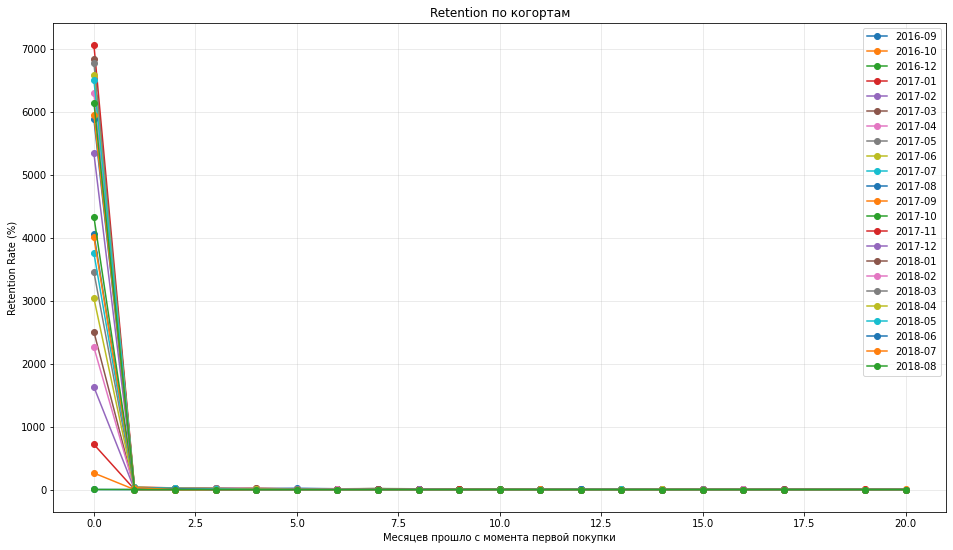

In [35]:
# График retention по месяцам
plt.figure(figsize=(16,9))
for cohort in retention_matrix.index:
    plt.plot(
        retention_matrix.columns, 
        retention_matrix.loc[cohort], 
        label=str(cohort),
        marker='o'
    )
plt.title('Retention по когортам')
plt.xlabel('Месяцев прошло с момента первой покупки')
plt.ylabel('Retention Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.



### Первая метрика должна отражать рост объёма продаж маркетплейса.
GMV (Gross Merchandise Value, или валовая стоимость товара)


In [36]:
# Расчет GMV по месяцам
orders['order_month'] = pd.to_datetime(orders['order_purchase_timestamp']).dt.to_period('M')
gmv_data = items.merge(orders[['order_id', 'order_month', 'order_status']], on='order_id')
gmv_monthly = gmv_data[gmv_data['order_status'] == 'delivered'].groupby('order_month')['price'].sum().reset_index()

print(gmv_monthly.head())

  order_month      price
0     2016-09     134.97
1     2016-10   40325.11
2     2016-12      10.90
3     2017-01  111798.36
4     2017-02  234223.40


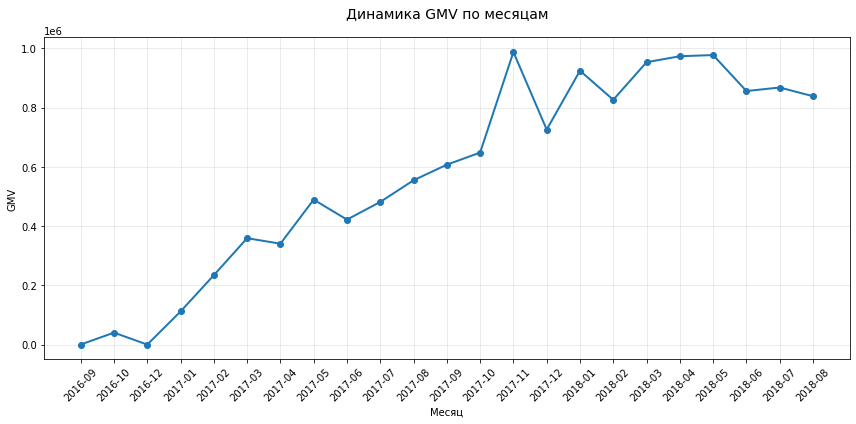

In [37]:
# Визуализация GMV
plt.figure(figsize=(12, 6))
plt.plot(gmv_monthly['order_month'].astype(str), gmv_monthly['price'], 
         marker='o', linewidth=2, markersize=6)
plt.title('Динамика GMV по месяцам', fontsize=14, pad=20)
plt.xlabel('Месяц')
plt.ylabel('GMV')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Вторая — показывать объем аудитории, которой продукт доставляет ценность.
Ценность из имеющихся данных - значит посылка доставлена

In [38]:
successful_orders = orders[orders['order_status'] == 'delivered']
successful_orders_with_customers = successful_orders.merge(
    customers[['customer_id', 'customer_unique_id']], 
    on='customer_id', 
    how='inner'
)

successful_customers_monthly = successful_orders_with_customers.groupby('order_month')['customer_unique_id'].nunique().reset_index()
successful_customers_monthly.rename(columns={'customer_unique_id': 'successful_customers'}, inplace=True)

print(successful_customers_monthly.head())

  order_month  successful_customers
0     2016-09                     1
1     2016-10                   262
2     2016-12                     1
3     2017-01                   718
4     2017-02                  1630


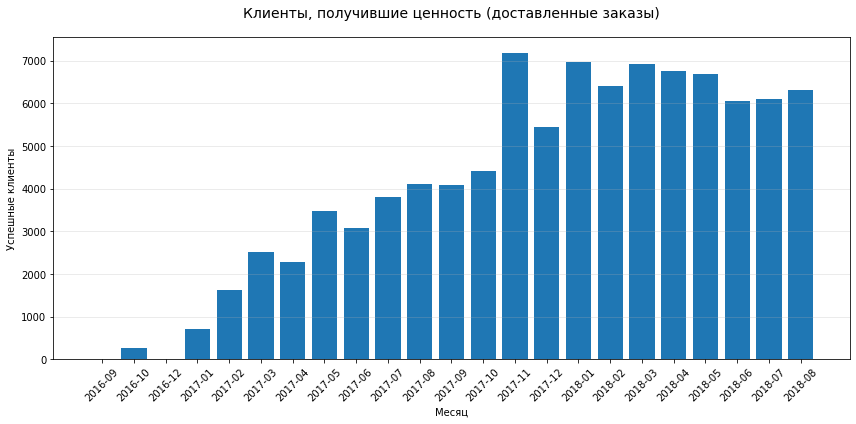

In [39]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.bar(successful_customers_monthly['order_month'].astype(str), 
        successful_customers_monthly['successful_customers'])       
plt.title('Клиенты, получившие ценность (доставленные заказы)', fontsize=14, pad=20)
plt.xlabel('Месяц')
plt.ylabel('Успешные клиенты')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
New User Conversion Rate - Отражает заинтересованность новых клиентов в продукте

In [40]:
# ГИПОТЕТИЧЕСКАЯ ФОРМУЛА (данных нет)
#conversion_rate = (Количество_первых_покупок / Количество_новых_пользователей) * 100

### Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.

Repeat Purchase Rate - отражает вовлеченность клиента в продолжение использования продукта

In [41]:
# Расчет Repeat Purchase Rate
orders_with_customers['order_month'] = orders_with_customers['order_purchase_timestamp'].dt.to_period('M')
customer_order_counts = orders_with_customers.groupby('customer_unique_id')['order_id'].nunique()
repeat_customers = customer_order_counts[customer_order_counts > 1].index

repeat_data = orders_with_customers[orders_with_customers['customer_unique_id'].isin(repeat_customers)]
repeat_by_month = repeat_data.groupby('order_month')['customer_unique_id'].nunique().reset_index()
repeat_by_month.rename(columns={'customer_unique_id': 'repeat_customers'}, inplace=True)

In [42]:
repeat_by_month.head()

,order_month,repeat_customers
0,2016-10,12
1,2016-12,1
2,2017-01,53
3,2017-02,68
4,2017-03,126


In [43]:
repeat_data

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,2017-10
14,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04,ccafc1c3f270410521c3c6f3b249870f,2018-06
15,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06,6e26bbeaa107ec34112c64e1ee31c0f5,2018-01
44,d17dc4a904426827ca80f2ccb3a6be56,569cf68214806a39acc0f39344aea67f,delivered,2017-05-14 20:28:25,2017-05-14 20:42:45,2017-05-16 08:17:46,2017-05-25 09:14:31,2017-06-12,c2551ea089b7ebbc67a2ea8757152514,2017-05
56,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,delivered,2017-03-13 18:14:36,2017-03-13 18:14:36,2017-03-22 14:03:09,2017-04-06 13:37:16,2017-03-30,51838d41add414a0b1b989b7d251d9ee,2017-03
...,...,...,...,...,...,...,...,...,...,...
96336,a96157730ca02d9de4c4e4ac2fc49f2c,5b36926fe1592a897dfb56c425ad5b48,delivered,2018-02-06 08:38:54,2018-02-08 07:35:35,2018-02-08 23:46:30,2018-02-21 14:05:57,2018-03-09,e2492e4188991b6276a4a62a287a5451,2018-02
96348,58edf3f5f282ab91e0f6a6f2b85af02a,14945bc802d49b0f9f68f2ea8fd060c4,delivered,2018-05-07 09:01:58,2018-05-08 04:34:10,2018-05-10 12:35:00,2018-05-14 18:52:56,2018-05-30,62b8761192c86f4ead06f4a433096a2b,2018-05
96384,bfecb4ee6ab98bff69307aab578db48a,e6f5f771cdbc5d09c994f16c9af6523d,delivered,2018-03-17 12:52:37,2018-03-17 13:10:35,2018-03-20 17:47:33,2018-03-27 19:16:57,2018-04-12,dca9a13536adcef18c6c5859487347b1,2018-03
96456,1b4a0e6b19d0034b531655b41ea89623,ce5efd1b1d8a2fa290a871edd5c26cd6,delivered,2017-10-02 08:45:35,2017-10-02 08:56:53,2017-10-03 20:26:19,2017-10-06 16:58:25,2017-10-24,39fff7cb5873a7116b02234bd1e6c6dc,2017-10


In [44]:
# активные клиенты (совершившие хотя бы 1 заказ в месяце)
active_customers = orders_with_customers.groupby('order_month')['customer_unique_id'].nunique().reset_index()
active_customers.rename(columns={'customer_unique_id': 'active_customers'}, inplace=True)


In [45]:
# объединяем с активными клиентами для расчета процента
repeat_rate = active_customers.merge(repeat_by_month, on='order_month', how='left')
repeat_rate['repeat_customers'] = repeat_rate['repeat_customers'].fillna(0)
repeat_rate['repeat_rate'] = (repeat_rate['repeat_customers'] / repeat_rate['active_customers']) * 100

In [46]:
repeat_rate.head()

,order_month,active_customers,repeat_customers,repeat_rate
0,2016-09,1,0.0,0.000000
1,2016-10,262,12.0,4.580153
2,2016-12,1,1.0,100.000000
3,2017-01,718,53.0,7.381616
4,2017-02,1630,68.0,4.171779


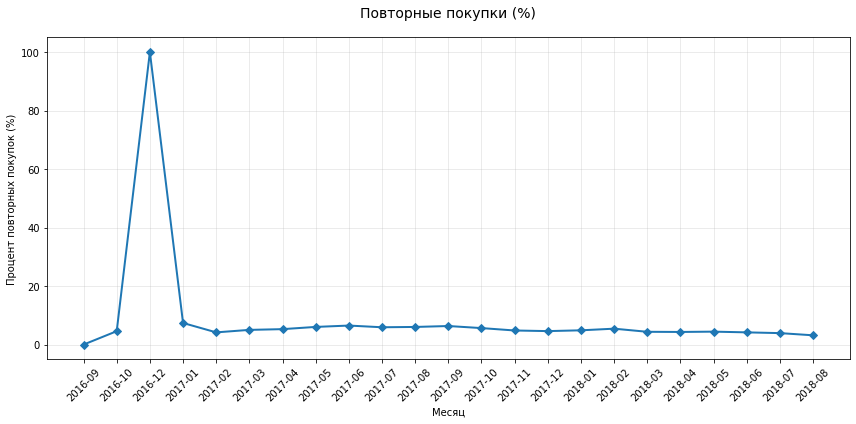

In [47]:
#Визуализация
plt.figure(figsize=(12, 6))
plt.plot(repeat_rate['order_month'].astype(str), repeat_rate['repeat_rate'], 
         marker='D', linewidth=2, markersize=6)
plt.title('Повторные покупки (%)', fontsize=14, pad=20)
plt.xlabel('Месяц')
plt.ylabel('Процент повторных покупок (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Пятая — отражать денежное выражение вовлеченности клиента.
Lifetime Value (LTV)- денежное выражение вовлеченности клиента

In [48]:
# Добавляем информацию о выручке к cohort_data
order_revenue = items.groupby('order_id')['price'].sum().reset_index()
cohort_with_revenue = cohort_data.merge(order_revenue, on='order_id')

# Расчет LTV по когортам
ltv_by_cohort = cohort_with_revenue.groupby(['cohort', 'customer_unique_id'])['price'].sum().reset_index()
cohort_ltv = ltv_by_cohort.groupby('cohort')['price'].mean().reset_index()
cohort_ltv.rename(columns={'price': 'avg_ltv'}, inplace=True)

In [49]:
ltv_by_cohort

,cohort,customer_unique_id,price
0,2016-09,830d5b7aaa3b6f1e9ad63703bec97d23,134.97
1,2016-10,0032c76b20340da25249092a268ce66c,128.90
2,2016-10,01f156677184504063bd19739f924af1,739.98
3,2016-10,0636d30c77f0f9cfad81f1c9b58c791f,949.99
4,2016-10,06bdfbbe1857c3c925ec81abfb1c9666,179.90
...,...,...,...
93353,2018-08,ffc39051848c3ef2be36d1513aa3ad17,28.00
93354,2018-08,ffc4e1cd8aa220763480d0a18157c45d,120.00
93355,2018-08,ffe204b1bb8026741b839085b2fd10f2,129.49
93356,2018-08,ffec490ab531184a483efe2eedd68908,39.90


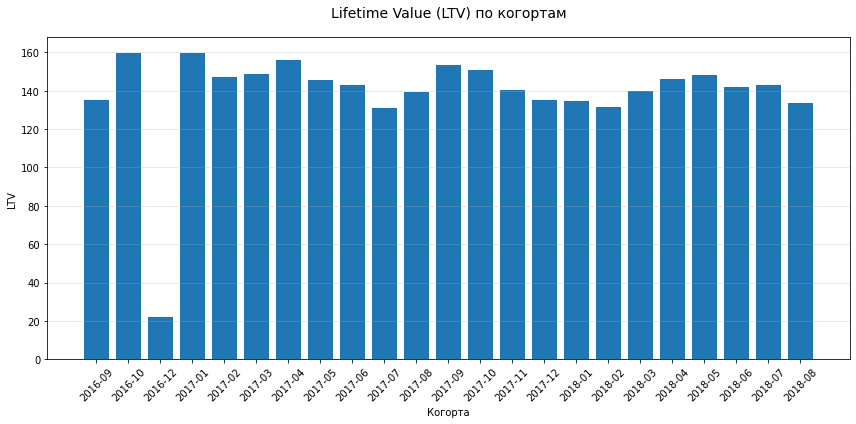

In [50]:
# Визуализация LTV
plt.figure(figsize=(12, 6))
plt.bar(cohort_ltv['cohort'].astype(str), cohort_ltv['avg_ltv'])
plt.title('Lifetime Value (LTV) по когортам', fontsize=14, pad=20)
plt.xlabel('Когорта')
plt.ylabel('LTV')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

In [51]:
june2017 = orders_with_customers[(orders_with_customers['order_purchase_timestamp'] >= '2017-06-01')]

In [52]:
june2017.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,2018-02


In [53]:
# Количество уникальных клиентов с июня 2017
unique_customers_june = june2017['customer_unique_id'].nunique()
print(f"Уникальных клиентов с июня 2017: {unique_customers_june}")

Уникальных клиентов с июня 2017: 82863


In [54]:
#Расчет по таблице impact
def impact_table(i):
    if i <=50:
        return 1
    elif i <= 150:
        return 2
    elif i <= 350:
        return 3
    elif i <= 750:
        return 4
    elif i <= 1550:
        return 5
    elif i <= 3150:
        return 6
    elif i <= 6350:
        return 7
    elif i <= 12750:
        return 8
    elif i <= 25550:
        return 9
    else:
        return 10

In [55]:
print(f"Медианный retention 1-го месяца: {median_retention_1m:.3f}%")

# конверсия в повторный заказ = медианный retention
conversion_rate = median_retention_1m/100   # Переводим в десятичную дробь
print(f"Конверсия в повторный заказ: {conversion_rate:.3f}")

Медианный retention 1-го месяца: 0.464%
Конверсия в повторный заказ: 0.005


In [56]:
# спасенные заказы могут конвертироваться в повторные с медианным retention
print('Гипотеза 1: Исправление бага в системе процессинга')
canceled_orders = orders[orders['order_status'].isin(['canceled', 'unavailable'])].shape[0]
saved_orders = canceled_orders
potential_repeat_from_saved = saved_orders * conversion_rate
impact_value_1 = impact_table(potential_repeat_from_saved)
print(f"Отмененных заказов: {canceled_orders}")
print(f"Конверсия в повторные: {conversion_rate:.6f}")
print(f"Потенциальных повторных заказов: {potential_repeat_from_saved:.0f}")
print(f"Impact: {impact_value_1}")

Гипотеза 1: Исправление бага в системе процессинга
Отмененных заказов: 1234
Конверсия в повторные: 0.004636
Потенциальных повторных заказов: 6
Impact: 1


In [57]:
# улучшаем retention на величину (10% от текущего)
current_retention = retention_rate[1].median()
retention_improvement = current_retention * 0.10  # 10% улучшение
additional_repeat = unique_customers_june * retention_improvement / 100
impact_value_2 = impact_table(additional_repeat)

print(f"ГИПОТЕЗА 2 - Сокращение времени доставки:")
print(f"Текущий retention: {current_retention:.6f}%")
print(f"Улучшение: +{retention_improvement:.6f}%")
print(f"Дополнительных повторных клиентов: {additional_repeat:.1f}")
print(f"Impact: {impact_value_2}")

ГИПОТЕЗА 2 - Сокращение времени доставки:
Текущий retention: 0.463634%
Улучшение: +0.046363%
Дополнительных повторных клиентов: 38.4
Impact: 1


In [58]:
# Правильные значения из нашего анализа
median_retention_1m = 0.464  # 0.464% (медианное значение)
current_retention = median_retention_1m

# Предположим количество уникальных клиентов с июня 2017
# Оценочно из ваших данных: 2017-06 когорта = 3037 клиентов
unique_customers_june = 3037  # Из вашей retention_matrix: 2017-06 когорта

# Улучшаем retention на 10% от текущего (очень оптимистично!)
retention_improvement = current_retention * 0.10  # 10% улучшение = +0.0464%

# Дополнительные повторные клиенты
additional_repeat = unique_customers_june * (retention_improvement / 100)  # Переводим в долю

print(f"ГИПОТЕЗА 2 - Сокращение времени доставки:")
print(f"Текущий медианный retention: {current_retention:.6f}%")
print(f"Улучшение (+10%): +{retention_improvement:.6f}%")
print(f"Размер когорты (июнь 2017): {unique_customers_june} клиентов")
print(f"Дополнительных повторных клиентов: {additional_repeat:.1f}")

ГИПОТЕЗА 2 - Сокращение времени доставки:
Текущий медианный retention: 0.464000%
Улучшение (+10%): +0.046400%
Размер когорты (июнь 2017): 3037 клиентов
Дополнительных повторных клиентов: 1.4


In [59]:
# Конвертируем однократных клиентов с медианным retention
print(f"ГИПОТЕЗА 3 - Новый способ оплаты:")

single_time_customers = unique_customers_june * (100 - current_retention) / 100
additional_conversions = single_time_customers * conversion_rate
impact_value_3 = impact_table(additional_conversions)

print(f"Клиентов без повторных покупок: {single_time_customers:.1f}")
print(f"Конверсия: {conversion_rate:.6f}")
print(f"Дополнительных конверсий: {additional_conversions:.1f}")
print(f"Impact: {impact_value_3}")

ГИПОТЕЗА 3 - Новый способ оплаты:
Клиентов без повторных покупок: 3022.9
Конверсия: 0.004636
Дополнительных конверсий: 14.0
Impact: 1


In [60]:
# Расчет ICE score
confidence = [8, 10, 5]
ease = [6,4,9]
impact = [impact_value_1, impact_value_2,impact_value_3]

ICE1 = confidence[0] * ease[0] * impact[0]
ICE2 = confidence[1] * ease[1] * impact[1]
ICE3 = confidence[2] * ease[2] * impact[2]

In [61]:
print(f'Исправление бага в системе процессинга заказов ICE = {ICE1}\nСокращение времени до отгрузки заказа ICE = {ICE2}\nСоздание нового способа оплаты ICE = {ICE3}')

Исправление бага в системе процессинга заказов ICE = 48
Сокращение времени до отгрузки заказа ICE = 40
Создание нового способа оплаты ICE = 45


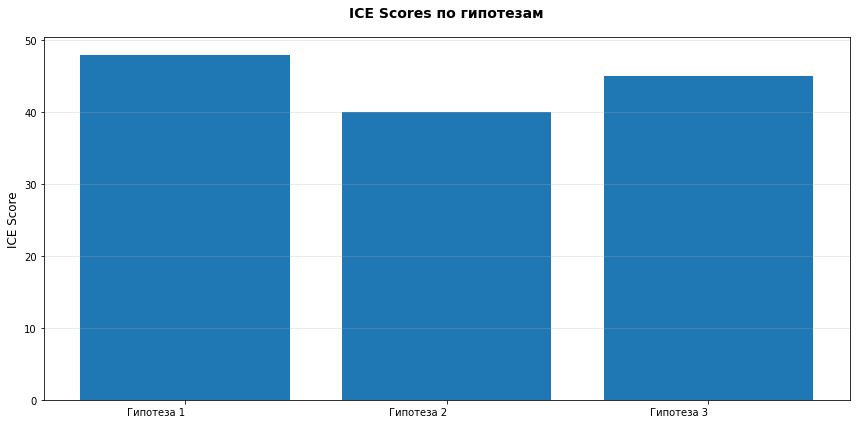

In [62]:
# Визуализация ICE scores
ice_scores = [ICE1, ICE2, ICE3]
hypothesis_names = [
    'Гипотеза 1', 
    'Гипотеза 2',
    'Гипотеза 3'
]

plt.figure(figsize=(12, 6))
bars = plt.bar(hypothesis_names, ice_scores)
plt.title('ICE Scores по гипотезам', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('ICE Score', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

## Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

### МЕТРИКИ ДЛЯ A/B-ТЕСТИРОВАНИЯ ГИПОТЕЗЫ:

**ЦЕЛЕВЫЕ МЕТРИКИ:**

1. **Repeat Purchase Rate**
   - Описание: Процент клиентов, совершивших повторную покупку
   - Цель: Увеличить на 25%
   - Почему: Прямо измеряет цель гипотезы - увеличение повторных покупок

2. **Retention Rate (1 месяц)**
   - Описание: Процент клиентов, вернувшихся через 1 месяц
   - Цель: Увеличить на 20%
   - Почему: Показывает долгосрочный эффект на удержание клиентов

**ПРОКСИ-МЕТРИКИ:**

3. **Conversion Rate нового способа оплаты**
   - Описание: Процент использования нового способа оплаты
   - Цель: > 15% уровня внедрения
   - Почему: Измеряет adoption rate нового функционала

4. **Time to First Repeat Purchase**
   - Описание: Время от первой до второй покупки
   - Цель: Сократить на 20%
   - Почему: Показывает, насколько быстрее клиенты возвращаются

**GUARDRAIL МЕТРИКИ:**

5. **Customer Support Tickets**
   - Описание: Количество обращений в поддержку
   - Цель: Без значительного роста
   - Почему: Контролирует нагрузку на поддержку от нового функционала

6. **Payment Failure Rate**
   - Описание: Процент неудачных транзакций
   - Цель: < 2% от всех транзакций
   - Почему: Обеспечивает техническую надежность платежной системы

7. **Average Order Value**
   - Описание: Средний чек
   - Цель: Без значительного снижения
   - Почему: Гарантирует, что удобство не приводит к уменьшению чека

# Отчет для Пети: Результаты анализа маркетплейса

## Формализация проблемы продукта
**Основная проблема**: Катастрофически низкий retention rate - 99.4% клиентов не возвращаются после первой покупки.

**Как мы это выявили**:
- Product/Market Fit отсутствует. Retention катастрофически низкий:
- Всего 0.46% пользователей возвращаются через месяц
- 99.5% клиентов совершают только одну покупку
- Кривая удержания резко падает до нуля

Как мы это поняли: через когортный анализ retention rate. Все показатели в 40-100 раз ниже industry standards.

**Основные выводы**
- Гибель retention: Пользователи не находят ценности для повторных покупок
- Нет лояльности: Бизнес работает как "одноразовый" - нет накопления клиентской базы
- Рост невозможен: Без повторных покупок выручка будет стагнировать

**Что делать**

*Срочно:*

- Починить ошибки в оформлении заказов (1234 отмененных заказа)
- Узнать у клиентов почему они не возвращаются - опросить их

*Основное:*

- Сделать новый способ оплаты - это даст наибольший эффект


**Главная цель**: Увеличить количество повторных покупок с 5 до 10 клиентов из 1000 в течение 3 месяцев.

**Важно:** Не тратить деньги на рекламу пока не починим основные проблемы. Сначала заставляем текущих клиентов возвращаться, потом привлекаем новых.